## model

In [1]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from langchain_core.chat_history import InMemoryChatMessageHistory
from langchain_core.chat_history import InMemoryChatMessageHistory
from typing import Annotated
from langgraph.graph.message import add_messages
from typing_extensions import TypedDict
from langgraph.graph import MessagesState
from langgraph.checkpoint.memory import MemorySaver

load_dotenv()

#llm
##################

llm = init_chat_model("ollama:nemotron-3-super:cloud",base_url="https://ollama.com")
llmg = init_chat_model("google_genai:gemini-2.5-flash")

response = llmg.invoke("What is the color of the sky answer in one word?")
print(response.content)

c:\E_DRIVE\Langraph-Refresher\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Blue


## SQL


#### Table Explanations

* Artist: Names of the music creators (e.g., AC/DC, Mozart).
* Album: Titles of the music albums.
* Track: The actual songs, including details like length, size, and price.
* Genre: Music categories (e.g., Rock, Jazz, Classical).
* MediaType: File formats (e.g., MPEG audio file, AAC audio file).
* Playlist: User-created collections of songs.
* PlaylistTrack: The link table that connects specific songs to specific playlists.
* Customer: Personal details of the people buying music.
* Employee: Information about the store's staff and who they report to.
* Invoice: The main receipt info (e.g., purchase date, billing address, total cost).
* InvoiceLine: The specific items bought in each receipt (which song, what price, quantity). [2] 



In [2]:
import pathlib
import requests

url = "https://storage.googleapis.com/benchmarks-artifacts/chinook/Chinook.db"
local_path = pathlib.Path("C:\E_DRIVE\Langraph-Refresher\database\Chinook.db")

if local_path.exists():
    print(f"{local_path} already exists, skipping download.")
else:
    response = requests.get(url, timeout=60)
    if response.status_code == 200:
        local_path.write_bytes(response.content)
        print(f"File downloaded and saved as {local_path}")
    else:
        print(f"Failed to download the file. Status code: {response.status_code}")

C:\E_DRIVE\Langraph-Refresher\database\Chinook.db already exists, skipping download.


## table name

In [5]:
import sqlite3

con = sqlite3.connect("C:\E_DRIVE\Langraph-Refresher\database\Chinook.db")

cursor = con.cursor()

# Query to fetch all table names
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()

# Loop through and print each table name
for table in tables:
    print(table[0])

# Clean up
cursor.close()


Album
Artist
Customer
Employee
Genre
Invoice
InvoiceLine
MediaType
Playlist
PlaylistTrack
Track


## Columns inside track table

In [6]:
cursor = con.cursor()

# Run the PRAGMA command for the Track table
cursor.execute("PRAGMA table_info(Track);")
columns = cursor.fetchall()

# Print header
print(f"{'Column ID':<10} | {'Column Name':<20} | {'Data Type':<15}")
print("-" * 50)

# Loop and print column details
for col in columns:
    # col[0] is ID, col[1] is Name, col[2] is Type
    print(f"{col[0]:<10} | {col[1]:<20} | {col[2]:<15}")

cursor.close()
con.close()

Column ID  | Column Name          | Data Type      
--------------------------------------------------
0          | TrackId              | INTEGER        
1          | Name                 | NVARCHAR(200)  
2          | AlbumId              | INTEGER        
3          | MediaTypeId          | INTEGER        
4          | GenreId              | INTEGER        
5          | Composer             | NVARCHAR(220)  
6          | Milliseconds         | INTEGER        
7          | Bytes                | INTEGER        
8          | UnitPrice            | NUMERIC(10,2)  


In [9]:
con = sqlite3.connect("C:\E_DRIVE\Langraph-Refresher\database\Chinook.db")

cursor = con.cursor()

# Run the PRAGMA command for the Track table
cursor.execute("PRAGMA table_info(Artist);")
columns = cursor.fetchall()

# Print header
print(f"{'Column ID':<10} | {'Column Name':<20} | {'Data Type':<15}")
print("-" * 50)

# Loop and print column details
for col in columns:
    # col[0] is ID, col[1] is Name, col[2] is Type
    print(f"{col[0]:<10} | {col[1]:<20} | {col[2]:<15}")

cursor.close()
con.close()

Column ID  | Column Name          | Data Type      
--------------------------------------------------
0          | ArtistId             | INTEGER        
1          | Name                 | NVARCHAR(120)  


In [10]:
con = sqlite3.connect("C:\E_DRIVE\Langraph-Refresher\database\Chinook.db")

cursor = con.cursor()

# Run the PRAGMA command for the Track table
cursor.execute("PRAGMA table_info(Album);")
columns = cursor.fetchall()

# Print header
print(f"{'Column ID':<10} | {'Column Name':<20} | {'Data Type':<15}")
print("-" * 50)

# Loop and print column details
for col in columns:
    # col[0] is ID, col[1] is Name, col[2] is Type
    print(f"{col[0]:<10} | {col[1]:<20} | {col[2]:<15}")

cursor.close()
con.close()

Column ID  | Column Name          | Data Type      
--------------------------------------------------
0          | AlbumId              | INTEGER        
1          | Title                | NVARCHAR(160)  
2          | ArtistId             | INTEGER        


In [11]:
columns

[(0, 'AlbumId', 'INTEGER', 1, None, 1),
 (1, 'Title', 'NVARCHAR(160)', 1, None, 0),
 (2, 'ArtistId', 'INTEGER', 1, None, 0)]

## 5 rows from thr track table

In [12]:
import sqlite3

con = sqlite3.connect("C:\\E_DRIVE\\Langraph-Refresher\\database\\Chinook.db")
cursor = con.cursor()

# Query to select all columns but restrict the output to 5 rows
cursor.execute("SELECT * FROM Track LIMIT 5;")
rows = cursor.fetchall()

# Loop through and print each row
for row in rows:
    print(row)

cursor.close()
con.close()


(1, 'For Those About To Rock (We Salute You)', 1, 1, 1, 'Angus Young, Malcolm Young, Brian Johnson', 343719, 11170334, 0.99)
(2, 'Balls to the Wall', 2, 2, 1, None, 342562, 5510424, 0.99)
(3, 'Fast As a Shark', 3, 2, 1, 'F. Baltes, S. Kaufman, U. Dirkscneider & W. Hoffman', 230619, 3990994, 0.99)
(4, 'Restless and Wild', 3, 2, 1, 'F. Baltes, R.A. Smith-Diesel, S. Kaufman, U. Dirkscneider & W. Hoffman', 252051, 4331779, 0.99)
(5, 'Princess of the Dawn', 3, 2, 1, 'Deaffy & R.A. Smith-Diesel', 375418, 6290521, 0.99)


## dataframe from the extracted dataset

In [ ]:
import sqlite3
import pandas as pd

# Connect to the database
con = sqlite3.connect("C:\\E_DRIVE\\Langraph-Refresher\\database\\Chinook.db")

# Read the SQL query directly into a pandas DataFrame
df = pd.read_sql_query("SELECT * FROM Track LIMIT 5;", con)

# Display the DataFrame
print(df)

# Close the connection
con.close()


In [14]:
df

,TrackId,Name,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice
0,1,For Those About To Rock (We Salute You),1,1,1,"Angus Young, Malcolm Young, Brian Johnson",343719,11170334,0.99
1,2,Balls to the Wall,2,2,1,NaN,342562,5510424,0.99
2,3,Fast As a Shark,3,2,1,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Ho...",230619,3990994,0.99
3,4,Restless and Wild,3,2,1,"F. Baltes, R.A. Smith-Diesel, S. Kaufman, U. D...",252051,4331779,0.99
4,5,Princess of the Dawn,3,2,1,Deaffy & R.A. Smith-Diesel,375418,6290521,0.99


In [15]:
import sqlite3
import pandas as pd

# 1. Connect to the database
con = sqlite3.connect("C:\\E_DRIVE\\Langraph-Refresher\\database\\Chinook.db")

# 2. Define your SQL query string
query = """
SELECT CustomerId, FirstName, LastName, Country, Email 
FROM Customer 
WHERE Country = 'USA';
"""

# 3. Read the data directly into a DataFrame
df = pd.read_sql_query(query, con)

# 4. Display the results
print(df)

# 5. Always close the connection
con.close()


    CustomerId FirstName    LastName Country                     Email
0           16     Frank      Harris     USA        fharris@google.com
1           17      Jack       Smith     USA   jacksmith@microsoft.com
2           18  Michelle      Brooks     USA         michelleb@aol.com
3           19       Tim       Goyer     USA          tgoyer@apple.com
4           20       Dan      Miller     USA       dmiller@comcast.com
5           21     Kathy       Chase     USA       kachase@hotmail.com
6           22   Heather     Leacock     USA        hleacock@gmail.com
7           23      John      Gordon     USA    johngordon22@yahoo.com
8           24     Frank     Ralston     USA        fralston@gmail.com
9           25    Victor     Stevens     USA        vstevens@yahoo.com
10          26   Richard  Cunningham     USA  ricunningham@hotmail.com
11          27   Patrick        Gray     USA      patrick.gray@aol.com
12          28     Julia     Barnett     USA       jubarnett@gmail.com


In [16]:
import sqlite3

con = sqlite3.connect("C:\\E_DRIVE\\Langraph-Refresher\\database\\Chinook.db")
cursor = con.cursor()

query = """
SELECT CustomerId, FirstName, LastName, Country, Email 
FROM Customer 
WHERE Country = 'USA';
"""

# Query to select all columns but restrict the output to 5 rows
cursor.execute(query)
rows = cursor.fetchall()

# Loop through and print each row
for row in rows:
    print(row)

cursor.close()
con.close()


(16, 'Frank', 'Harris', 'USA', 'fharris@google.com')
(17, 'Jack', 'Smith', 'USA', 'jacksmith@microsoft.com')
(18, 'Michelle', 'Brooks', 'USA', 'michelleb@aol.com')
(19, 'Tim', 'Goyer', 'USA', 'tgoyer@apple.com')
(20, 'Dan', 'Miller', 'USA', 'dmiller@comcast.com')
(21, 'Kathy', 'Chase', 'USA', 'kachase@hotmail.com')
(22, 'Heather', 'Leacock', 'USA', 'hleacock@gmail.com')
(23, 'John', 'Gordon', 'USA', 'johngordon22@yahoo.com')
(24, 'Frank', 'Ralston', 'USA', 'fralston@gmail.com')
(25, 'Victor', 'Stevens', 'USA', 'vstevens@yahoo.com')
(26, 'Richard', 'Cunningham', 'USA', 'ricunningham@hotmail.com')
(27, 'Patrick', 'Gray', 'USA', 'patrick.gray@aol.com')
(28, 'Julia', 'Barnett', 'USA', 'jubarnett@gmail.com')


In [18]:
Q = """SELECT Name, Milliseconds, Bytes 
FROM Track 
ORDER BY Milliseconds DESC 
LIMIT 10;
"""

In [21]:
import sqlite3

con = sqlite3.connect("C:\\E_DRIVE\\Langraph-Refresher\\database\\Chinook.db")
cursor = con.cursor()

query = Q



# 3. Read the data directly into a DataFrame
df = pd.read_sql_query(query, con)

# 4. Display the results
print(df)

# 5. Always close the connection
con.close()

                          Name  Milliseconds       Bytes
0       Occupation / Precipice       5286953  1054423946
1      Through a Looking Glass       5088838  1059546140
2  Greetings from Earth, Pt. 1       2960293   536824558
3      The Man With Nine Lives       2956998   577829804
4  Battlestar Galactica, Pt. 2       2956081   521387924
5  Battlestar Galactica, Pt. 1       2952702   541359437
6    Murder On the Rising Star       2935894   551759986
7  Battlestar Galactica, Pt. 3       2927802   554509033
8            Take the Celestra       2927677   512381289
9                Fire In Space       2926593   536784757


In [22]:
q = """SELECT Country, COUNT(CustomerId) AS TotalCustomers
FROM Customer
GROUP BY Country
ORDER BY TotalCustomers DESC;
"""


q = """SELECT Album.Title, Artist.Name AS ArtistName
FROM Album
INNER JOIN Artist ON Album.ArtistId = Artist.ArtistId;
"""


q = """SELECT TrackId, Name, Composer 
FROM Track 
WHERE Name LIKE '%Love%';

"""

## table names Atrists rows

In [23]:
import sqlite3

con = sqlite3.connect("C:\\E_DRIVE\\Langraph-Refresher\\database\\Chinook.db")
cursor = con.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = [row[0] for row in cursor.fetchall() if not row[0].startswith("sqlite_")]

print("Dialect: sqlite")
print(f"Available tables: {tables}")

cursor.execute("SELECT * FROM Artist LIMIT 5;")
print(f"Sample output: {cursor.fetchall()}")
con.close()

Dialect: sqlite
Available tables: ['Album', 'Artist', 'Customer', 'Employee', 'Genre', 'Invoice', 'InvoiceLine', 'MediaType', 'Playlist', 'PlaylistTrack', 'Track']
Sample output: [(1, 'AC/DC'), (2, 'Accept'), (3, 'Aerosmith'), (4, 'Alanis Morissette'), (5, 'Alice In Chains')]


In [25]:
con = sqlite3.connect("C:\\E_DRIVE\\Langraph-Refresher\\database\\Chinook.db")
cursor = con.cursor()
query = "SELECT name FROM sqlite_master WHERE type='table';"
# 3. Read the data directly into a DataFrame
df = pd.read_sql_query(query, con)
# 4. Display the results
print(df)
# 5. Always close the connection
con.close()

             name
0           Album
1          Artist
2        Customer
3        Employee
4           Genre
5         Invoice
6     InvoiceLine
7       MediaType
8        Playlist
9   PlaylistTrack
10          Track


In [ ]:
con = sqlite3.connect("C:\\E_DRIVE\\Langraph-Refresher\\database\\Chinook.db")
cursor = con.cursor()
query = "SELECT * FROM Artist LIMIT 5;"
# 3. Read the data directly into a DataFrame
df = pd.read_sql_query(query, con)
# 4. Display the results
print(df)
# 5. Always close the connection
con.close()

   ArtistId               Name
0         1              AC/DC
1         2             Accept
2         3          Aerosmith
3         4  Alanis Morissette
4         5    Alice In Chains


## . Add tools for database interactions

In [45]:
import sqlite3
from langchain.tools import tool
DB_PATH = "C:\\E_DRIVE\\Langraph-Refresher\\database\\Chinook.db"


@tool
def sql_db_list_tables() -> str:
    """Input is an empty string, output is a comma-separated list of tables in the database."""
    con = sqlite3.connect(DB_PATH)
    try:
        cursor = con.cursor()
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        tables = [
            row[0]
            for row in cursor.fetchall()
            if not row[0].startswith("sqlite_")
        ]
        return ", ".join(tables)
    finally:
        con.close()


@tool
def sql_db_schema(table_names: str) -> str:
    """Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables.
    Be sure that the tables actually exist by calling sql_db_list_tables first!
    Example Input: table1, table2, table3"""
    con = sqlite3.connect(DB_PATH)
    try:
        cursor = con.cursor()
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        valid_tables = {
            row[0] for row in cursor.fetchall() if not row[0].startswith("sqlite_")
        }
        results = []
        for table in table_names.split(","):
            table = table.strip()
            if table not in valid_tables:
                results.append(
                    f"Error: table_names {{{table!r}}} not found in database"
                )
                continue
            cursor.execute(
                "SELECT sql FROM sqlite_master WHERE type='table' AND name=?;",
                (table,),
            )
            schema_row = cursor.fetchone()
            if schema_row:
                results.append(schema_row[0])
                try:
                    quoted_table = '"' + table.replace('"', '""') + '"'
                    cursor.execute(f"SELECT * FROM {quoted_table} LIMIT 3;")
                    rows = cursor.fetchall()
                    if rows:
                        col_names = [description[0] for description in cursor.description]
                        results.append(
                            f"/*\n3 rows from {table} table:\n"
                            + "\t".join(col_names)
                            + "\n"
                            + "\n".join(
                                "\t".join(str(x) for x in row) for row in rows
                            )
                            + "\n*/"
                        )
                except Exception as e:
                    results.append(f"Error fetching sample rows: {e}")
        return "\n\n".join(results)
    finally:
        con.close()


@tool
def sql_db_query(query: str) -> str:
    """Input to this tool is a detailed and correct SQL query, output is a result from the database.
    If the query is not correct, an error message will be returned.
    If an error is returned, rewrite the query, check the query, and try again.
    If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields."""
    con = sqlite3.connect(DB_PATH)
    try:
        cursor = con.cursor()
        cursor.execute(query)
        res = cursor.fetchall()
        return str(res)
    except Exception as e:
        return f"Error: {e}"
    finally:
        con.close()


tools = [sql_db_list_tables, sql_db_schema, sql_db_query]

for tool in tools:
    print(f"{tool.name}: {tool.description}\n")

sql_db_list_tables: Input is an empty string, output is a comma-separated list of tables in the database.

sql_db_schema: Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables.
    Be sure that the tables actually exist by calling sql_db_list_tables first!
    Example Input: table1, table2, table3

sql_db_query: Input to this tool is a detailed and correct SQL query, output is a result from the database.
    If the query is not correct, an error message will be returned.
    If an error is returned, rewrite the query, check the query, and try again.
    If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.



In [33]:
# ==========================================
# SAMPLE INVOCATIONS USING .invoke()
# ==========================================

print("--- 1. Testing sql_db_list_tables ---")
# This tool expects an empty string as per its docstring description
list_result = sql_db_list_tables.invoke("")
print(list_result)
print("\n" + "=" * 50 + "\n")

--- 1. Testing sql_db_list_tables ---
Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track




1. The exact SQL CREATE TABLE statement used to build them (showing all columns and data types).
2. A preview of the first 3 data rows formatted as tab-separated values

In [ ]:
print("--- 2. Testing sql_db_schema ---")
# Pass a single string or a dictionary containing the schema input keyword argument
schema_result = sql_db_schema.invoke({"table_names": "Track, Customer"})
print(schema_result)
print("\n" + "=" * 50 + "\n")




--- 2. Testing sql_db_schema ---
CREATE TABLE [Track]
(
    [TrackId] INTEGER  NOT NULL,
    [Name] NVARCHAR(200)  NOT NULL,
    [AlbumId] INTEGER,
    [MediaTypeId] INTEGER  NOT NULL,
    [GenreId] INTEGER,
    [Composer] NVARCHAR(220),
    [Milliseconds] INTEGER  NOT NULL,
    [Bytes] INTEGER,
    [UnitPrice] NUMERIC(10,2)  NOT NULL,
    CONSTRAINT [PK_Track] PRIMARY KEY  ([TrackId]),
    FOREIGN KEY ([AlbumId]) REFERENCES [Album] ([AlbumId]) 
		ON DELETE NO ACTION ON UPDATE NO ACTION,
    FOREIGN KEY ([GenreId]) REFERENCES [Genre] ([GenreId]) 
		ON DELETE NO ACTION ON UPDATE NO ACTION,
    FOREIGN KEY ([MediaTypeId]) REFERENCES [MediaType] ([MediaTypeId]) 
		ON DELETE NO ACTION ON UPDATE NO ACTION
)

/*
3 rows from Track table:
TrackId	Name	AlbumId	MediaTypeId	GenreId	Composer	Milliseconds	Bytes	UnitPrice
1	For Those About To Rock (We Salute You)	1	1	1	Angus Young, Malcolm Young, Brian Johnson	343719	11170334	0.99
2	Balls to the Wall	2	2	1	None	342562	5510424	0.99
3	Fast As a Shark	

In [31]:
sample_sql = """SELECT Country, COUNT(CustomerId) AS TotalCustomers
FROM Customer
GROUP BY Country
ORDER BY TotalCustomers DESC;
"""

query_result = sql_db_query.invoke({"query": sample_sql})
print(query_result)

[('USA', 13), ('Canada', 8), ('France', 5), ('Brazil', 5), ('Germany', 4), ('United Kingdom', 3), ('Portugal', 2), ('India', 2), ('Czech Republic', 2), ('Sweden', 1), ('Spain', 1), ('Poland', 1), ('Norway', 1), ('Netherlands', 1), ('Italy', 1), ('Ireland', 1), ('Hungary', 1), ('Finland', 1), ('Denmark', 1), ('Chile', 1), ('Belgium', 1), ('Austria', 1), ('Australia', 1), ('Argentina', 1)]


### 4. Define application steps
We construct dedicated nodes for the following steps:

    Listing DB tables
    Calling the “get schema” tool
    Generating a query
    Checking the query

In [36]:
from typing import Literal
from langchain.messages import AIMessage
from langchain_core.runnables import RunnableConfig
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode


In [ ]:
tools = [sql_db_list_tables, sql_db_schema, sql_db_query]
for tool in tools:
    print(f"{tool.name}: {tool.description}\n")

sql_db_list_tables: Input is an empty string, output is a comma-separated list of tables in the database.

sql_db_schema: Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables.
    Be sure that the tables actually exist by calling sql_db_list_tables first!
    Example Input: table1, table2, table3

sql_db_query: Input to this tool is a detailed and correct SQL query, output is a result from the database.
    If the query is not correct, an error message will be returned.
    If an error is returned, rewrite the query, check the query, and try again.
    If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.



In [47]:
# get schema
tools = [sql_db_list_tables, sql_db_schema, sql_db_query]
get_schema_tool = next(tool for tool in tools if tool.name == "sql_db_schema")
get_schema_node = ToolNode([get_schema_tool], name="get_schema")

# run query
run_query_tool = next(tool for tool in tools if tool.name == "sql_db_query")
run_query_node = ToolNode([run_query_tool], name="run_query")

get_schema_tool, get_schema_node

(StructuredTool(name='sql_db_schema', description='Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables.\n    Be sure that the tables actually exist by calling sql_db_list_tables first!\n    Example Input: table1, table2, table3', args_schema=<class 'langchain_core.utils.pydantic.sql_db_schema'>, func=<function sql_db_schema at 0x000001121B0C3380>),
 get_schema(tags=None, recurse=True, explode_args=False, func_accepts={'config': ('N/A', <class 'inspect._empty'>), 'runtime': ('N/A', <class 'inspect._empty'>)}, _tools_by_name={'sql_db_schema': StructuredTool(name='sql_db_schema', description='Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables.\n    Be sure that the tables actually exist by calling sql_db_list_tables first!\n    Example Input: table1, table2, table3', args_schema=<class 'langchain_core.utils.pydantic.sql_db_schema'>, func=<function sql_db_schema at 0x0000011

In [40]:
print(get_schema_node)

get_schema(tags=None, recurse=True, explode_args=False, func_accepts={'config': ('N/A', <class 'inspect._empty'>), 'runtime': ('N/A', <class 'inspect._empty'>)}, _tools_by_name={'sql_db_schema': StructuredTool(name='sql_db_schema', description='Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables.\n    Be sure that the tables actually exist by calling sql_db_list_tables first!\n    Example Input: table1, table2, table3', args_schema=<class 'langchain_core.utils.pydantic.sql_db_schema'>, func=<function sql_db_schema at 0x0000011219F360C0>)}, _injected_args={'sql_db_schema': _InjectedArgs(state={}, store=None, runtime=None, all_injected_keys=set(), _optional_state_args=set())}, _handle_tool_errors=<function _default_handle_tool_errors at 0x0000011219F06020>, _messages_key='messages', _wrap_tool_call=None, _awrap_tool_call=None)


In [48]:
# Example: create a predetermined tool call
def list_tables(state: MessagesState):
    tool_call = {
        "name": "sql_db_list_tables",
        "args": {},
        "id": "abc123",
        "type": "tool_call",
    }
    tool_call_message = AIMessage(content="", tool_calls=[tool_call])

    list_tables_tool = next(tool for tool in tools if tool.name == "sql_db_list_tables")
    tool_message = list_tables_tool.invoke(tool_call)
    response = AIMessage(f"Available tables: {tool_message.content}")

    return {"messages": [tool_call_message, tool_message, response]}

In [ ]:
from langchain_core.messages import HumanMessage

# 1. Create a fake state representing a user's question
mock_state = {
    "messages": [HumanMessage(content="Show me data from this database.")]
}
# 2. Call the function directly and pass your mock state
output_state = list_tables(mock_state)
# 3. Print the newly appended messages returned by the function
for msg in output_state["messages"]:
    print(f"[{msg.__class__.__name__}]: {msg.content}")


[AIMessage]: 
[ToolMessage]: Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track
[AIMessage]: Available tables: Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track


In [50]:
output_state

{'messages': [AIMessage(content='', additional_kwargs={}, response_metadata={}, tool_calls=[{'name': 'sql_db_list_tables', 'args': {}, 'id': 'abc123', 'type': 'tool_call'}], invalid_tool_calls=[]),
  ToolMessage(content='Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track', name='sql_db_list_tables', tool_call_id='abc123'),
  AIMessage(content='Available tables: Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]}

In [52]:
# Example: force a model to create a tool call
def call_get_schema(state: MessagesState):
    # Note that LangChain enforces that all models accept `tool_choice="any"`
    # as well as `tool_choice=<string name of tool>`.
    llm_with_tools = llm.bind_tools([get_schema_tool], tool_choice="any")
    response = llm_with_tools.invoke(state["messages"])

    return {"messages": [response]}


In [58]:
generate_query_system_prompt = """
You are an agent designed to interact with a SQL database.
Given an input question, create a syntactically correct {dialect} query to run,
then look at the results of the query and return the answer. Unless the user
specifies a specific number of examples they wish to obtain, always limit your
query to at most {top_k} results.

You can order the results by a relevant column to return the most interesting
examples in the database. Never query for all the columns from a specific table,
only ask for the relevant columns given the question.

DO NOT make any DML statements (INSERT, UPDATE, DELETE, DROP etc.) to the database.
""".format(
    dialect="sqlite",
    top_k=5,
)

model = llmg

def generate_query(state: MessagesState):
    system_message = {
        "role": "system",
        "content": generate_query_system_prompt,
    }
    # We do not force a tool call here, to allow the model to
    # respond naturally when it obtains the solution.
    llm_with_tools = model.bind_tools([run_query_tool])
    response = llm_with_tools.invoke([system_message] + state["messages"])

    return {"messages": [response]}

In [59]:
check_query_system_prompt = """
You are a SQL expert with a strong attention to detail.
Double check the {dialect} query for common mistakes, including:
- Using NOT IN with NULL values
- Using UNION when UNION ALL should have been used
- Using BETWEEN for exclusive ranges
- Data type mismatch in predicates
- Properly quoting identifiers
- Using the correct number of arguments for functions
- Casting to the correct data type
- Using the proper columns for joins

If there are any of the above mistakes, rewrite the query. If there are no mistakes,
just reproduce the original query.

You will call the appropriate tool to execute the query after running this check.
""".format(dialect="sqlite")


model = llm

def check_query(state: MessagesState):
    system_message = {
        "role": "system",
        "content": check_query_system_prompt,
    }

    # Generate an artificial user message to check
    tool_call = state["messages"][-1].tool_calls[0]
    user_message = {"role": "user", "content": tool_call["args"]["query"]}
    llm_with_tools = model.bind_tools([run_query_tool], tool_choice="any")
    response = llm_with_tools.invoke([system_message, user_message])
    response.id = state["messages"][-1].id

    return {"messages": [response]}


## final Agent

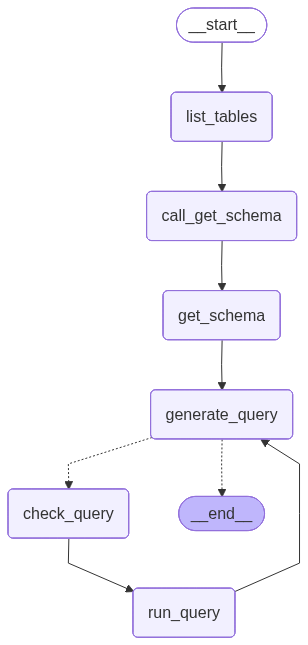

In [60]:
def should_continue(state: MessagesState) -> Literal[END, "check_query"]:
    messages = state["messages"]
    last_message = messages[-1]
    if not last_message.tool_calls:
        return END
    else:
        return "check_query"


builder = StateGraph(MessagesState)
builder.add_node(list_tables)
builder.add_node(call_get_schema)
builder.add_node(get_schema_node, "get_schema")
builder.add_node(generate_query)
builder.add_node(check_query)
builder.add_node(run_query_node, "run_query")

builder.add_edge(START, "list_tables")
builder.add_edge("list_tables", "call_get_schema")
builder.add_edge("call_get_schema", "get_schema")
builder.add_edge("get_schema", "generate_query")
builder.add_conditional_edges(
    "generate_query",
    should_continue,
)
builder.add_edge("check_query", "run_query")
builder.add_edge("run_query", "generate_query")

agent = builder.compile()
agent

In [61]:
question = "Which genre on average has the longest tracks?"

stream = agent.stream_events(
    {"messages": [{"role": "user", "content": question}]},
    version="v3",
)
for message in stream.messages:
    for token in message.text:
        print(token, end="", flush=True)

final_state = stream.output

Available tables: Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, TrackWe need average track length per genre, find genre with highest average track length.

We need to join Track with Genre, maybe track length in milliseconds column (Milliseconds). Compute average per genre, order descending.

We need to use sql_db_schema to see columns, but we can infer typical Chinook database: Track table has Name, AlbumId, MediaTypeId, GenreId, Composer, Milliseconds, Bytes, UnitPrice. Genre table has GenreId, Name. So we need to join.

We'll call sql_db_schema for Track and Genre.
</think>The genre with the longest average track length is **Sci Fi & Fantasy**, with an average track length of approximately **2,911,783 milliseconds** (about 48.5 minutes).

In [62]:
final_state

{'messages': [HumanMessage(content='Which genre on average has the longest tracks?', additional_kwargs={}, response_metadata={}, id='8cd38a9b-0eff-462d-a367-f9f82a70d3f4'),
  AIMessage(content='', additional_kwargs={}, response_metadata={}, id='3a7fc0a9-0e20-4e97-b8f0-fa4950c369e8', tool_calls=[{'name': 'sql_db_list_tables', 'args': {}, 'id': 'abc123', 'type': 'tool_call'}], invalid_tool_calls=[]),
  ToolMessage(content='Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track', name='sql_db_list_tables', id='9eb1a381-efbf-446d-b349-f249af878e11', tool_call_id='abc123'),
  AIMessage(content='Available tables: Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track', additional_kwargs={}, response_metadata={}, id='552a1096-87e6-45ea-86d5-c1964dff2286', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content=[{'type': 'tool_call', 'id': 'df8a75b4-a63d-4dab-9207-20686c825bd8', 'name': 'sq

In [67]:
for m in final_state['messages']:
    m.pretty_print()

================================ Human Message =================================

Which genre on average has the longest tracks?
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (abc123)
 Call ID: abc123
  Args:
================================= Tool Message =================================
Name: sql_db_list_tables

Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track
================================== Ai Message ==================================

Available tables: Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track
================================== Ai Message ==================================

[{'type': 'tool_call', 'id': 'df8a75b4-a63d-4dab-9207-20686c825bd8', 'name': 'sql_db_schema', 'args': {'table_names': 'Track, Genre'}}]
Tool Calls:
  sql_db_schema (df8a75b4-a63d-4dab-9207-20686c825bd8)
 Call ID: df8a75b4-

In [68]:
question = "How many total employees work at the company?"

stream = agent.stream_events(
    {"messages": [{"role": "user", "content": question}]},
    version="v3",
)
for message in stream.messages:
    for token in message.text:
        print(token, end="", flush=True)

final_state = stream.output

Available tables: Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, TrackWe need number of total employees. Use Employee table. Need to get schema? Not strictly necessary; we can query count of rows. But we need to use sql_db_schema tool? The instruction: "When users ask questions, you MUST use the available tools." Likely need to use sql_db_schema to get schema? But we just need count, not schema. However requirement: must use available tools. We could use sql_db_schema to get schema of Employee table, then maybe infer count? Not provided. Actually schema tool returns schema and sample rows; sample rows may include data? Possibly includes some rows but not all. Safer to use sql_db_schema to get schema and sample rows; then we could count from sample? Not reliable. Better to query directly? There is no query tool besides schema. But perhaps we can use sql_db_schema to get schema, then we can infer that count is number of rows? Not given

In [69]:
final_state

{'messages': [HumanMessage(content='How many total employees work at the company?', additional_kwargs={}, response_metadata={}, id='b81ac865-a69f-442e-a713-156cda850395'),
  AIMessage(content='', additional_kwargs={}, response_metadata={}, id='aa523325-4455-4ed0-a41a-ff31711db032', tool_calls=[{'name': 'sql_db_list_tables', 'args': {}, 'id': 'abc123', 'type': 'tool_call'}], invalid_tool_calls=[]),
  ToolMessage(content='Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track', name='sql_db_list_tables', id='31768ff3-5047-4b7c-b039-e283293696fd', tool_call_id='abc123'),
  AIMessage(content='Available tables: Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track', additional_kwargs={}, response_metadata={}, id='4c841908-2b0b-4197-9eee-0b2c463f7763', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content=[{'type': 'tool_call', 'id': '014bde42-8e0a-4cb2-af95-4e1f2b01772b', 'name': 'sql

In [70]:
for m in final_state['messages']:
    m.pretty_print()

================================ Human Message =================================

How many total employees work at the company?
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (abc123)
 Call ID: abc123
  Args:
================================= Tool Message =================================
Name: sql_db_list_tables

Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track
================================== Ai Message ==================================

Available tables: Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track
================================== Ai Message ==================================

[{'type': 'tool_call', 'id': '014bde42-8e0a-4cb2-af95-4e1f2b01772b', 'name': 'sql_db_schema', 'args': {'table_names': 'Employee'}}]
Tool Calls:
  sql_db_schema (014bde42-8e0a-4cb2-af95-4e1f2b01772b)
 Call ID: 014bde42-8e0a-

## combined code 

In [ ]:
from typing import Literal
from langchain.messages import AIMessage
from langchain_core.runnables import RunnableConfig
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode



tools = [sql_db_list_tables, sql_db_schema, sql_db_query]



get_schema_tool = next(tool for tool in tools if tool.name == "sql_db_schema")
get_schema_node = ToolNode([get_schema_tool], name="get_schema")

run_query_tool = next(tool for tool in tools if tool.name == "sql_db_query")
run_query_node = ToolNode([run_query_tool], name="run_query")


# Example: create a predetermined tool call
def list_tables(state: MessagesState):
    tool_call = {
        "name": "sql_db_list_tables",
        "args": {},
        "id": "abc123",
        "type": "tool_call",
    }
    tool_call_message = AIMessage(content="", tool_calls=[tool_call])

    list_tables_tool = next(tool for tool in tools if tool.name == "sql_db_list_tables")
    tool_message = list_tables_tool.invoke(tool_call)
    response = AIMessage(f"Available tables: {tool_message.content}")

    return {"messages": [tool_call_message, tool_message, response]}


# Example: force a model to create a tool call
def call_get_schema(state: MessagesState):
    # Note that LangChain enforces that all models accept `tool_choice="any"`
    # as well as `tool_choice=<string name of tool>`.
    llm_with_tools = model.bind_tools([get_schema_tool], tool_choice="any")
    response = llm_with_tools.invoke(state["messages"])

    return {"messages": [response]}


generate_query_system_prompt = """
You are an agent designed to interact with a SQL database.
Given an input question, create a syntactically correct {dialect} query to run,
then look at the results of the query and return the answer. Unless the user
specifies a specific number of examples they wish to obtain, always limit your
query to at most {top_k} results.

You can order the results by a relevant column to return the most interesting
examples in the database. Never query for all the columns from a specific table,
only ask for the relevant columns given the question.

DO NOT make any DML statements (INSERT, UPDATE, DELETE, DROP etc.) to the database.
""".format(
    dialect="sqlite",
    top_k=5,
)


def generate_query(state: MessagesState):
    system_message = {
        "role": "system",
        "content": generate_query_system_prompt,
    }
    # We do not force a tool call here, to allow the model to
    # respond naturally when it obtains the solution.
    llm_with_tools = model.bind_tools([run_query_tool])
    response = llm_with_tools.invoke([system_message] + state["messages"])

    return {"messages": [response]}


check_query_system_prompt = """
You are a SQL expert with a strong attention to detail.
Double check the {dialect} query for common mistakes, including:
- Using NOT IN with NULL values
- Using UNION when UNION ALL should have been used
- Using BETWEEN for exclusive ranges
- Data type mismatch in predicates
- Properly quoting identifiers
- Using the correct number of arguments for functions
- Casting to the correct data type
- Using the proper columns for joins

If there are any of the above mistakes, rewrite the query. If there are no mistakes,
just reproduce the original query.

You will call the appropriate tool to execute the query after running this check.
""".format(dialect="sqlite")


def check_query(state: MessagesState):
    system_message = {
        "role": "system",
        "content": check_query_system_prompt,
    }

    # Generate an artificial user message to check
    tool_call = state["messages"][-1].tool_calls[0]
    user_message = {"role": "user", "content": tool_call["args"]["query"]}
    llm_with_tools = model.bind_tools([run_query_tool], tool_choice="any")
    response = llm_with_tools.invoke([system_message, user_message])
    response.id = state["messages"][-1].id

    return {"messages": [response]}